
===== Iteration 0 =====
UB_global = 1.981988
LB_iter   = -0.048846
ms_iter   = -2.332338e+00

== Per-triangle summary ==
row\simp  *T0*         **T1*         *
----------------------------------
UB        *   -0.043408**   -0.344842*
LB        *   -0.048846**   -0.345390*
ms        *  -2.031e+00**  -2.332e+00*
(列带 * 表示 active simplex；行分别是 UB / LB / ms)


===== Iteration 1 =====
UB_global = -0.344842
LB_iter   = -1.338824
ms_iter   = -1.429915e+00

== Per-triangle summary ==
row\simp  *T0*         **T1*         **T2*         **T3*         *
----------------------------------------------------------
UB        *   -0.344842**   -0.344842**   -0.344842**   -0.344842*
LB        *   -1.374920**   -1.338824**   -1.774757**   -1.422222*
ms        *  -1.030e+00**  -9.940e-01**  -1.430e+00**  -1.077e+00*
(列带 * 表示 active simplex；行分别是 UB / LB / ms)


===== Iteration 2 =====
UB_global = -0.344842
LB_iter   = -0.497555
ms_iter   = -1.381743e+00

== Per-triangle summary ==
row\simp  *T0*         **T

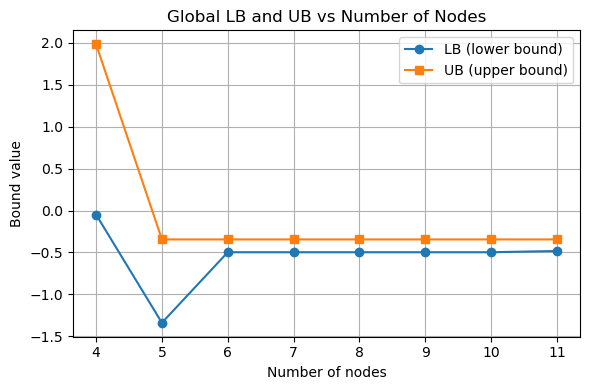

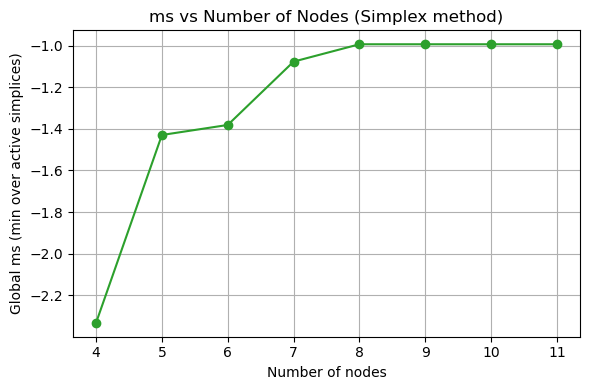


==== Summary Table ====
   Nodes |           ms |           LB |           UB
-----------------------------------------------------
       4 |      -2.3323 |      -0.0488 |       1.9820
       5 |      -1.4299 |      -1.3388 |      -0.3448
       6 |      -1.3817 |      -0.4976 |      -0.3448
       7 |      -1.0774 |      -0.4976 |      -0.3448
       8 |      -0.9940 |      -0.4976 |      -0.3448
       9 |      -0.9940 |      -0.4976 |      -0.3448
      10 |      -0.9940 |      -0.4976 |      -0.3448
      11 |      -0.9940 |      -0.4828 |      -0.3448
-----------------------------------------------------
   Total |            8


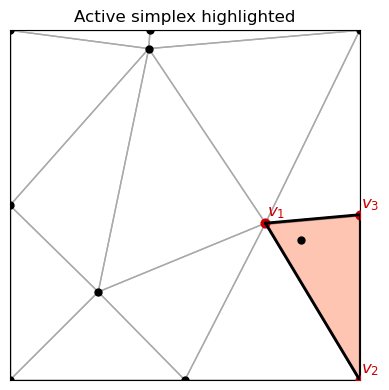

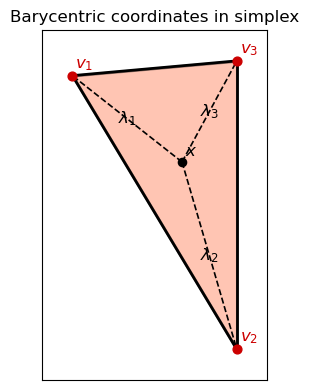


==== Done ====
Total nodes: 12
Best expected f among nodes: -0.344842
If figures were generated, they were saved as:
  overall_active_simplex.png
  barycentric_simplex.png

Use these PNGs in Slide 1 (barycentric) and Slide 3 (active simplex).

Math to paste in Slide 1:
  x = \lambda_1 v_1 + \lambda_2 v_2 + \lambda_3 v_3,  \sum_i \lambda_i = 1, \lambda_i \ge 0
  A_s(x) = \lambda_1 A_s(v_1) + \lambda_2 A_s(v_2) + \lambda_3 A_s(v_3).


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection, PolyCollection
from scipy.spatial import Delaunay

import pyomo.environ as pyo
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


# ============================================================
# 0. 全局场景容器
# ============================================================

SCENARIOS = []


# ============================================================
# 1. 多场景 (期望) 目标函数
# ============================================================

def eval_single_gaussian(x, y, scen):
    """
    一个带高斯坑和外部二次偏置的场景目标:
        f_s(x,y) = - depth * exp(- ||(x,y)-center||^2 / width^2 )
                   + outer_bias_strength * ||(x,y)-bias_center||^2
                   + offset
    """
    cx, cy   = scen["center"]
    depth    = scen["depth"]
    width    = scen["width"]
    bs       = scen["outer_bias_strength"]
    bcx, bcy = scen["outer_bias_center"]
    offset   = scen["offset"]

    well_term = - depth * np.exp(-(((x-cx)**2 + (y-cy)**2)/(width**2)))
    bias_term = bs * ((x-bcx)**2 + (y-bcy)**2)
    return well_term + bias_term + offset


def f_true_numpy(xy):
    """
    期望目标 E[f(x,y)] = sum_s p_s * f_s(x,y)
    xy: (2,) numpy array
    """
    x = float(xy[0])
    y = float(xy[1])
    total = 0.0
    for scen in SCENARIOS:
        ps = scen["p"]
        total += ps * eval_single_gaussian(x, y, scen)
    return total


def f_true_expr(m):
    """
    Pyomo表达式版本 E[f(x,y)]
    """
    expr = 0
    for scen in SCENARIOS:
        ps = float(scen["p"])
        cx, cy   = float(scen["center"][0]), float(scen["center"][1])
        depth    = float(scen["depth"])
        width    = float(scen["width"])
        bs       = float(scen["outer_bias_strength"])
        bcx, bcy = float(scen["outer_bias_center"][0]), float(scen["outer_bias_center"][1])
        offset   = float(scen["offset"])

        term_well = -depth * pyo.exp(-(((m.x - cx)**2 + (m.y - cy)**2)/(width**2)))
        term_bias = bs * ((m.x - bcx)**2 + (m.y - bcy)**2)

        expr += ps * (term_well + term_bias + offset)

    return expr


# ============================================================
# 2. 构建 Pyomo 模型 + first-stage 变量
# ============================================================

def build_model():
    m = pyo.ConcreteModel()
    # 定义一阶段变量及其范围
    m.x = pyo.Var(bounds=(0.0, 10.0))
    m.y = pyo.Var(bounds=(0.0, 10.0))
    fsv = [m.x, m.y]  # first-stage variables
    return m, fsv


# ============================================================
# 3. 根据 fsv 的 bounds 生成所有角点 (2^d)
# ============================================================

def generate_corners(fsv):
    lows  = []
    highs = []
    for v in fsv:
        lo = v.lb
        hi = v.ub
        if lo is None or hi is None:
            raise ValueError(f"Var {v.name} bounds invalid: lb={lo}, ub={hi}")
        if lo > hi:
            raise ValueError(f"Var {v.name} lb>ub: lb={lo}, ub={hi}")
        lows.append(float(lo))
        highs.append(float(hi))

    lows  = np.array(lows, dtype=float)
    highs = np.array(highs, dtype=float)

    d = len(fsv)
    if d == 0:
        raise ValueError("No first-stage variables in fsv.")

    nodes = []
    for mask in range(1 << d):  # 遍历0..2^d-1
        point = []
        for i in range(d):
            if (mask >> i) & 1:
                point.append(highs[i])
            else:
                point.append(lows[i])
        nodes.append(np.array(point, dtype=float))
    return nodes  # list of np.array([x,y])


# ============================================================
# 4. 评估角点的(期望)目标值
# ============================================================

def evaluate_objective_at(node):
    return f_true_numpy(node)


# ============================================================
# 5. 对每个 Delaunay 三角形求 ms / LB / UB
#    (这是 active simplex refinement 的核心信息)
# ============================================================

def minimize_on_each_triangle(nodes, values, solver='ipopt', tee=False):
    """
    nodes: list of R^2 points
    values: list of f_true_numpy(node)
    返回:
      tri: Delaunay剖分对象
      results: 列表, 每个元素是一个字典:
        {
            "simplex_index": k,
            "vertices_index": [i1,i2,i3],
            "verts": array((3,2)),
            "fverts": array((3,)),
            "x_ms": array([x*,y*])  # 使 gap 最坏的点
            "ms": ms_val,
            "LB": LB,
            "UB": UB,
            ...
        }
    """
    pts  = np.asarray(nodes, dtype=float)   # (N,2)
    vals = np.asarray(values, dtype=float)  # (N,)
    tri = Delaunay(pts)                     # tri.simplices: (K,3)

    # 基模型
    m_base, _ = build_model()

    opt = pyo.SolverFactory(solver)
    if solver == "gurobi":
        opt.options["NonConvex"] = 2

    results = []
    for k, simp in enumerate(tri.simplices):
        verts  = pts[simp]     # (3,2)
        fverts = vals[simp]    # (3,)

        # clone
        m = m_base.clone()

        # barycentric λ_j
        m.lam = pyo.Var(range(3), domain=pyo.NonNegativeReals)
        m.lam_sum = pyo.Constraint(expr=sum(m.lam[j] for j in range(3)) == 1.0)

        # x,y 用重心坐标线性组合顶点
        m.x_link_x = pyo.Constraint(
            expr=m.x == sum(m.lam[j]*float(verts[j,0]) for j in range(3))
        )
        m.x_link_y = pyo.Constraint(
            expr=m.y == sum(m.lam[j]*float(verts[j,1]) for j in range(3))
        )

        # 线性插值代理 As = Σ λ_j f(v_j)
        m.As = pyo.Var()
        m.As_con = pyo.Constraint(
            expr=m.As == sum(m.lam[j]*float(fverts[j]) for j in range(3))
        )

        # 目标: min E[f(x,y)] - As  => 这是局部 "ms"
        m.obj = pyo.Objective(expr=f_true_expr(m) - m.As,
                              sense=pyo.minimize)

        res = opt.solve(m, tee=tee)

        x_ms = np.array([pyo.value(m.x), pyo.value(m.y)], dtype=float)
        ms_val = float(pyo.value(m.obj))

        f_at_x_ms = f_true_numpy(x_ms)      # 真函数在 x_ms 的值
        LB = float(np.min(fverts) + ms_val) # LB估计
        UB = float(min(np.min(fverts), f_at_x_ms))  # UB估计

        results.append({
            "simplex_index": int(k),
            "vertices_index": simp.tolist(),
            "verts": verts,
            "fverts": fverts,
            "x_ms": x_ms,
            "ms": ms_val,
            "LB": LB,
            "UB": UB,
            "f(x_ms)": f_at_x_ms,
            "status": str(res.solver.status),
            "term": str(res.solver.termination_condition),
        })

    return tri, results


# ============================================================
# 6. 计算当前迭代的全局LB (0th-order lower bound flavor)
# ============================================================

def compute_lb_min_node_max_ms(nodes, values, per_tri):
    """
    我们用当前最优节点 v* 以及与它相邻的三角形里最大的 ms
    来更新一个全局 LB。
    返回:
      LB_iter: float
      idx_min: 最优节点的index
      ms_star: 与该节点相邻单形的最大ms
    """
    idx_min = int(np.argmin(values))
    ms_candidates = [r['ms'] for r in per_tri if idx_min in r['vertices_index']]
    if ms_candidates:
        return float(values[idx_min] + max(ms_candidates)), idx_min, float(max(ms_candidates))
    # fallback: 取所有LB里最小的
    fallback = float(min(r['LB'] for r in per_tri))
    return fallback, idx_min, float('nan')


# ============================================================
# 7. 选新节点策略：按 ms 排序，跳过太近的点
# ============================================================

def pick_candidate_by_ms_rank(per_tri, nodes, min_dist=1e-6, descending=False):
    """
    per_tri 里每个r包含 "ms" 和 "x_ms"
    我们按 ms 从小到大(默认)选，要求新点离已有节点不太近
    """
    cands = sorted(per_tri, key=lambda r: r['ms'], reverse=descending)

    def ok(p):
        return all(np.linalg.norm(p - q) >= min_dist for q in nodes)

    for rank, r in enumerate(cands, start=1):
        p = np.array(r['x_ms'], float)
        if ok(p):
            return p, rank, float(r['ms'])
    return None, None, None


# ============================================================
# 8. 打印每个三角形的信息表 (带 active mask)
# ============================================================

def print_per_triangle_table(results, active_mask):
    results_sorted = sorted(results, key=lambda r: r["simplex_index"])
    simplex_ids = [r["simplex_index"] for r in results_sorted]
    active_set = {sid for sid in simplex_ids if active_mask[sid]}

    header = ["row\\simp"] + [f"T{sid}{'*' if sid in active_set else ''}" for sid in simplex_ids]
    rows = [
        ["UB"] + [f"{r['UB']:.6f}" for r in results_sorted],
        ["LB"] + [f"{r['LB']:.6f}" for r in results_sorted],
        ["ms"] + [f"{r['ms']:.3e}" for r in results_sorted],
    ]
    table = [header] + rows

    ncols = len(header)
    colw = [0]*ncols
    for c in range(ncols):
        colw[c] = max(len(str(row[c])) for row in table) + 2

    def colorize_if_active(col_idx: int, s: str) -> str:
        # 这里我们简化: 直接返回原文字，不加终端颜色控制
        if col_idx == 0:
            return s
        sid = simplex_ids[col_idx-1]
        if sid in active_set:
            return f"*{s}*"
        return s

    header_line = "".join(
        colorize_if_active(c, str(header[c]).ljust(colw[c]))
        for c in range(ncols)
    )

    print("\n== Per-triangle summary ==")
    print(header_line)
    print("-" * sum(colw))

    for r in rows:
        line = []
        for c in range(ncols):
            cell = str(r[c])
            padded = cell.ljust(colw[c]) if c == 0 else cell.rjust(colw[c])
            line.append(colorize_if_active(c, padded))
        print("".join(line))

    print("(列带 * 表示 active simplex；行分别是 UB / LB / ms)\n")


# ============================================================
# 9. 每一轮迭代的3D可视化 (真实曲面 + active simplex的As+ms屋顶)
#    这个图不是必须用于PPT，但对debug和展示算法有帮助
# ============================================================

def plot_iteration(iter_id, nodes, tri, active_mask,
                   grid_n=60, elev=35, azim=-135,
                   min_node=None, new_node=None,
                   per_tri=None):
    nodes = np.asarray(nodes, float)

    COLOR_SURFACE = 'C0'           # 真实期望函数曲面
    COLOR_NODE_EDGES = '#444444'   # active 单形在真实曲面上的边
    COLOR_PIECE = '#ff7043'        # As+ms 屋顶
    LW_MAIN = 2.2

    # 画期望函数曲面 z = E[f(x,y)]
    xs = np.linspace(0, 10, grid_n)
    ys = np.linspace(0, 10, grid_n)
    XX, YY = np.meshgrid(xs, ys)
    ZZ = np.zeros_like(XX)
    for i in range(XX.shape[0]):
        for j in range(XX.shape[1]):
            ZZ[i,j] = f_true_numpy([XX[i,j], YY[i,j]])

    fig = plt.figure(figsize=(7,5))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(XX, YY, ZZ, alpha=0.35, linewidth=0,
                    antialiased=True, color=COLOR_SURFACE)

    if per_tri is not None and len(per_tri) > 0 and tri is not None:
        # As + ms (active simplex屋顶)
        faces = []
        for r in per_tri:
            sid = r["simplex_index"]
            if not active_mask.get(sid, False):
                continue
            verts_xy = r["verts"]     # (3,2)
            fverts   = r["fverts"]    # (3,)
            ms_val   = r["ms"]
            tri_xyz  = [
                (verts_xy[i,0], verts_xy[i,1], float(fverts[i] + ms_val))
                for i in range(3)
            ]
            faces.append(tri_xyz)

        if faces:
            coll = Poly3DCollection(
                faces,
                facecolors=['#ff7043'],
                edgecolors='none',
                alpha=0.55
            )
            ax.add_collection3d(coll)

        # active simplex边，在As+ms高度处
        for r in per_tri:
            sid = r["simplex_index"]
            if not active_mask.get(sid, False):
                continue
            verts_xy = r["verts"]
            fverts   = r["fverts"]
            ms_val   = r["ms"]
            for i in range(3):
                a_xy = verts_xy[i]
                b_xy = verts_xy[(i+1) % 3]
                za = float(fverts[i] + ms_val)
                zb = float(fverts[(i+1) % 3] + ms_val)
                ax.plot([a_xy[0], b_xy[0]],
                        [a_xy[1], b_xy[1]],
                        [za, zb],
                        lw=LW_MAIN, c='#444444')

    # 所有当前节点(黑点)
    node_z = np.array([f_true_numpy(p) for p in nodes])
    ax.scatter(nodes[:,0], nodes[:,1], node_z,
               s=30, c='k', depthshade=False)

    # 当前全局最优节点(绿色)
    if min_node is not None:
        ax.scatter([min_node[0]], [min_node[1]],
                   [f_true_numpy(min_node)],
                   color='g', s=80, marker='o', label='Current min node')

    # 新挑选的点(蓝色)
    if new_node is not None:
        ax.scatter([new_node[0]], [new_node[1]],
                   [f_true_numpy(new_node)],
                   color='b', s=80, marker='o', label='Next node')

    ax.set_title(f"Iteration {iter_id}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("E[f(x,y)]")
    ax.legend(loc='upper left')
    ax.view_init(elev=elev, azim=azim)

    plt.tight_layout()
    plt.show()


# ============================================================
# 10. 收敛曲线 (LB / UB / ms vs node_count)
# ============================================================

def plot_convergence(hist, prec=4):
    x  = hist["node_count"]
    LB = hist["LB_hist"]
    UB = hist["UB_hist"]
    ms = hist["ms_hist"]

    plt.figure(figsize=(6,4))
    plt.plot(x, LB, marker='o', label="LB (lower bound)")
    plt.plot(x, UB, marker='s', label="UB (upper bound)")
    plt.xlabel("Number of nodes")
    plt.ylabel("Bound value")
    plt.title("Global LB and UB vs Number of Nodes")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(x, ms, marker='o', color='C2')
    plt.xlabel("Number of nodes")
    plt.ylabel("Global ms (min over active simplices)")
    plt.title("ms vs Number of Nodes (Simplex method)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 简单控制台表
    print("\n==== Summary Table ====")
    fmt = f"{{:.{prec}f}}"
    header = f"{'Nodes':>8s} | {'ms':>12s} | {'LB':>12s} | {'UB':>12s}"
    print(header)
    print("-" * len(header))
    for n, m_val, lb, ub in zip(x, ms, LB, UB):
        print(f"{n:8d} | {fmt.format(m_val):>12s} | {fmt.format(lb):>12s} | {fmt.format(ub):>12s}")
    print("-" * len(header))
    print(f"{'Total':>8s} | {len(x):>12d}")


# ============================================================
# 11. 画PPT用2D图：
#   (a) 全局 triangulation + active simplex 高亮
#   (b) 选中单形 + 重心坐标 λ1,λ2,λ3
# ============================================================

ORANGE = "#ff7043"
GRAY   = "#aaaaaa"
BLACK  = "#000000"
RED    = "#cc0000"

def pick_active_simplex(per_tri, active_mask):
    """
    选一个需要高亮的单形:
      - 优先在active simplex里选ms最小的
      - 如果没有active，则在所有三角形中选ms最小的
    """
    active_list = [r for r in per_tri if active_mask.get(r["simplex_index"], False)]
    if len(active_list) == 0:
        active_list = per_tri
    r_best = min(active_list, key=lambda r: r["ms"])
    return r_best
def plot_active_simplex_overall(nodes, tri, per_tri, active_mask,
                                savepath="overall_active_simplex.png",
                                show_inline=True):
    nodes = np.asarray(nodes, float)

    # 选出那个 active simplex
    chosen = pick_active_simplex(per_tri, active_mask)
    verts_xy = np.asarray(chosen["verts"])          # (3,2)
    idxs     = chosen["vertices_index"]             # indices into nodes

    # 全部三角网的边
    segs = []
    for simplex in tri.simplices:
        tri_pts = nodes[simplex]
        for i in range(3):
            a = tri_pts[i]
            b = tri_pts[(i+1) % 3]
            segs.append([a, b])
    segs = np.array(segs)

    fig, ax = plt.subplots(figsize=(4,4))

    # 灰线
    lc = LineCollection(segs, colors=GRAY, linewidths=1.0, zorder=1)
    ax.add_collection(lc)

    # 橙色填充+黑边
    poly = PolyCollection([verts_xy],
                          facecolors=[ORANGE],
                          edgecolors=[BLACK],
                          linewidths=[2.0],
                          alpha=0.4,
                          zorder=2)
    ax.add_collection(poly)

    # 全部点
    ax.scatter(nodes[:,0], nodes[:,1],
               c=BLACK, s=25, zorder=3)

    # 高亮顶点
    for local_id, global_id in enumerate(idxs):
        vx, vy = nodes[global_id]
        ax.scatter([vx],[vy], c=RED, s=40, zorder=4)
        ax.text(vx+0.05, vy+0.05,
                f"$v_{local_id+1}$",
                color=RED, fontsize=12,
                ha='left', va='bottom',
                zorder=5)

    # 单形轮廓再黑描一遍
    for i in range(3):
        a = verts_xy[i]
        b = verts_xy[(i+1) % 3]
        ax.plot([a[0], b[0]], [a[1], b[1]],
                color=BLACK, linewidth=2.0, zorder=6)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(0,10)
    ax.set_ylim(0,10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("Active simplex highlighted", fontsize=12, color="black")

    plt.tight_layout()
    fig.savefig(savepath, dpi=300)

    if show_inline:
        display(fig)

    plt.close(fig)
    return chosen


def plot_barycentric_local(chosen_simplex,
                           savepath="barycentric_simplex.png",
                           show_inline=True):
    verts_xy = np.asarray(chosen_simplex["verts"])   # (3,2)
    x_pt = verts_xy.mean(axis=0)  # 重心点用三角形质心

    fig, ax = plt.subplots(figsize=(4,4))

    # 橙色单形
    poly = PolyCollection([verts_xy],
                          facecolors=[ORANGE],
                          edgecolors=[BLACK],
                          linewidths=[2.0],
                          alpha=0.4,
                          zorder=1)
    ax.add_collection(poly)

    # 黑边
    for i in range(3):
        a = verts_xy[i]
        b = verts_xy[(i+1) % 3]
        ax.plot([a[0], b[0]], [a[1], b[1]],
                color=BLACK, linewidth=2.0, zorder=2)

    # 三个顶点 v1,v2,v3
    for local_id in range(3):
        vx, vy = verts_xy[local_id]
        ax.scatter([vx],[vy], c=RED, s=40, zorder=4)
        ax.text(vx+0.05, vy+0.05,
                f"$v_{local_id+1}$",
                color=RED, fontsize=12,
                ha='left', va='bottom',
                zorder=5)

    # 点 x
    ax.scatter([x_pt[0]],[x_pt[1]], c=BLACK, s=35, zorder=5)
    ax.text(x_pt[0]+0.05, x_pt[1]+0.05,
            r"$x$", color=BLACK,
            fontsize=12,
            ha='left', va='bottom',
            zorder=6)

    # λ_i 虚线
    for local_id in range(3):
        vx, vy = verts_xy[local_id]
        ax.plot([x_pt[0], vx], [x_pt[1], vy],
                linestyle="--", color=BLACK,
                linewidth=1.2, zorder=3)
        midx = 0.5*(x_pt[0] + vx)
        midy = 0.5*(x_pt[1] + vy)
        ax.text(midx, midy,
                rf"$\lambda_{{{local_id+1}}}$",
                fontsize=12,
                ha='center', va='center',
                color=BLACK,
                zorder=7)

    # 轴
    pad = 0.5
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(min(verts_xy[:,0]) - pad, max(verts_xy[:,0]) + pad)
    ax.set_ylim(min(verts_xy[:,1]) - pad, max(verts_xy[:,1]) + pad)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("Barycentric coordinates in simplex", fontsize=12, color="black")

    plt.tight_layout()
    fig.savefig(savepath, dpi=300)

    if show_inline:
        display(fig)

    plt.close(fig)


# ============================================================
# 12. 主循环 (主动单形 refinement)
#     我们在这里会一轮轮加点，直到达到 max_nodes
#     并返回收敛历史 + 最后一轮的 tri / per_tri / active_mask
# ============================================================

def run_case(
    init_nodes,
    init_values,
    max_nodes=10,
    solver='ipopt',
    tee=False,
    plot_grid_n=60,
    record_history=True,
    make_3d_plots=True,
    only_from_active=True,
    min_dist=1e-4,
    active_tol=1e-8,
    print_tables=True
):
    nodes  = [np.array(p, dtype=float) for p in init_nodes]
    values = [float(v) for v in init_values]

    LB_hist, UB_hist, ms_hist, node_count = [], [], [], []

    # 我们提前初始化，避免 None
    last_tri = None
    last_per_tri = None
    last_active_mask = {}
    last_idx_min_node = None

    it = 0
    while len(nodes) < max_nodes:
        # ====== 本轮求三角剖分 + ms ======
        tri, per_tri = minimize_on_each_triangle(
            nodes, values, solver=solver, tee=tee
        )

        UB_global = float(np.min(values))

        LB_iter, idx_min_node, ms_chosen = compute_lb_min_node_max_ms(
            nodes, values, per_tri
        )

        ms_iter = min(r['ms'] for r in per_tri)

        if record_history:
            LB_hist.append(LB_iter)
            UB_hist.append(UB_global)
            ms_hist.append(ms_iter)
            node_count.append(len(nodes))

        # active simplex 判定
        active_mask = {
            r['simplex_index']: (r['LB'] <= UB_global + active_tol)
            for r in per_tri
        }
        active_tris = [r for r in per_tri if active_mask[r['simplex_index']]]

        # 新点候选
        candidates = active_tris if (only_from_active and len(active_tris) > 0) else per_tri
        if only_from_active and len(active_tris) == 0 and print_tables:
            print(f"[warn] No active simplices this round (tol={active_tol:g}); using all simplices.")
        new_node, used_rank, used_ms = pick_candidate_by_ms_rank(
            candidates, nodes,
            min_dist=min_dist,
            descending=False
        )

        # 打印表
        if print_tables:
            print(f"\n===== Iteration {it} =====")
            print(f"UB_global = {UB_global:.6f}")
            print(f"LB_iter   = {LB_iter:.6f}")
            print(f"ms_iter   = {ms_iter:.6e}")
            print_per_triangle_table(per_tri, active_mask)

        # 3D (可关掉)
        if make_3d_plots and len(nodes[0]) == 2:
            plot_iteration(
                it, nodes, tri, active_mask,
                grid_n=plot_grid_n,
                min_node=nodes[idx_min_node],
                new_node=new_node,
                per_tri=per_tri
            )

        # —— 重要：无论后面break不break，先保存本轮状态 ——
        last_tri = tri
        last_per_tri = per_tri
        last_active_mask = active_mask
        last_idx_min_node = idx_min_node

        # 退出条件1：没有新点
        if new_node is None:
            break
        # 退出条件2：新点太靠近现有点
        if any(np.linalg.norm(new_node - q) < min_dist for q in nodes):
            break

        # 否则把新点加入，继续下一轮
        nodes.append(new_node)
        values.append(f_true_numpy(new_node))

        it += 1

    # 全部结束，返回
    return {
        "nodes": np.array(nodes),
        "values": np.array(values),
        "LB_hist": LB_hist,
        "UB_hist": UB_hist,
        "ms_hist": ms_hist,
        "node_count": node_count,
        "last_tri": last_tri,
        "last_per_tri": last_per_tri,
        "last_active_mask": last_active_mask,
        "last_idx_min_node": last_idx_min_node,
    }



# ============================================================
# 13. 随机生成场景
# ============================================================

def random_scenarios(num_scenarios,
                     domain_low=0.0, domain_high=10.0,
                     depth_range=(0.8, 2.0),
                     width_range=(0.8, 2.0),
                     bias_strength_range=(0.02, 0.08),
                     bias_center=(5.0,5.0),
                     offset=0.0,
                     seed=None):
    rng = np.random.default_rng(seed)
    scens = []
    for _ in range(num_scenarios):
        cx = rng.uniform(domain_low, domain_high)
        cy = rng.uniform(domain_low, domain_high)
        depth = rng.uniform(*depth_range)
        width = rng.uniform(*width_range)
        bs = rng.uniform(*bias_strength_range)
        scens.append({
            "center": np.array([cx, cy], dtype=float),
            "depth": float(depth),
            "width": float(width),
            "outer_bias_strength": float(bs),
            "outer_bias_center": np.array(bias_center, dtype=float),
            "offset": float(offset),
        })
    # 均匀权重
    pval = 1.0/len(scens)
    for s in scens:
        s["p"] = pval
    return scens


# ============================================================
# 14. 主程序：一键跑完 + 生成PPT图
# ============================================================
def main():
    global SCENARIOS

    # 1. 随机场景
    SCENARIOS = random_scenarios(num_scenarios=3, seed=42)

    # 2. 变量边界 -> 初始角点
    model_for_bounds, fsv = build_model()
    init_nodes = generate_corners(fsv)
    init_values = [evaluate_objective_at(p) for p in init_nodes]

    # 3. 主迭代
    hist = run_case(
        init_nodes=init_nodes,
        init_values=init_values,
        max_nodes=12,
        solver="ipopt",
        tee=False,
        plot_grid_n=60,
        record_history=True,
        make_3d_plots=False,      # True 也行，会多出3D图
        only_from_active=True,
        min_dist=1e-4,
        active_tol=1e-8,
        print_tables=True
    )

    # 4. 收敛曲线（这两张线图你已经看到了）
    plot_convergence(hist, prec=4)

    # 5. 生成PPT图片
    nodes       = hist["nodes"]
    tri         = hist["last_tri"]
    per_tri     = hist["last_per_tri"]
    active_mask = hist["last_active_mask"]

    if tri is None or per_tri is None or active_mask is None:
        print("\n[warn] No triangulation info captured; cannot draw simplex figures.")
    else:
        chosen = plot_active_simplex_overall(
            nodes,
            tri,
            per_tri,
            active_mask,
            savepath="overall_active_simplex.png",
            show_inline=True   # notebook 里直接显示
        )

        plot_barycentric_local(
            chosen,
            savepath="barycentric_simplex.png",
            show_inline=True   # notebook 里直接显示
        )

    # 6. 最后总结
    best_val = float(np.min(hist["values"]))
    print("\n==== Done ====")
    print(f"Total nodes: {len(hist['nodes'])}")
    print(f"Best expected f among nodes: {best_val:.6f}")
    print("If figures were generated, they were saved as:")
    print("  overall_active_simplex.png")
    print("  barycentric_simplex.png")
    print("\nUse these PNGs in Slide 1 (barycentric) and Slide 3 (active simplex).")
    print("\nMath to paste in Slide 1:")
    print(r"  x = \lambda_1 v_1 + \lambda_2 v_2 + \lambda_3 v_3,  \sum_i \lambda_i = 1, \lambda_i \ge 0")
    print(r"  A_s(x) = \lambda_1 A_s(v_1) + \lambda_2 A_s(v_2) + \lambda_3 A_s(v_3).")


# 运行主程序
main()
